# **1. Entendimiento del negocio**
En una clínica de ginecobstetricia, en la que se cuenta con la información de 2.126 histogramas a fetos. Se pide construir un modelo de clasificación que sea capaz de determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca. El modelo debería contar con un desempeño superior al 85% en accuracy y con la mejor matriz de confusión y f1 score posible.

# **2.Enfoque analítico**

Desarrollar un experimento de clasificación para determinar si un feto es normal, sospechoso o cuenta con alguna patología cardiaca con un desempeño esperado mayor al 85%.

# **3. Recolección de datos**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

##Importación de los datos
data = pd.read_csv('datos_caso_2.csv')
data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sb

# **5. Entendimiento de los datos**

- Análisis de Completitud: calidad de datos
- Análisis Univariado: entender cada variable
- Análisis Bivariado: relaciones simples entre variables
- Análisis Multivariado: relaciones complejas entre más de 2 variables

- Datos nulos
- Desbalance de y (fetal_health)

In [3]:
#Identificación de datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

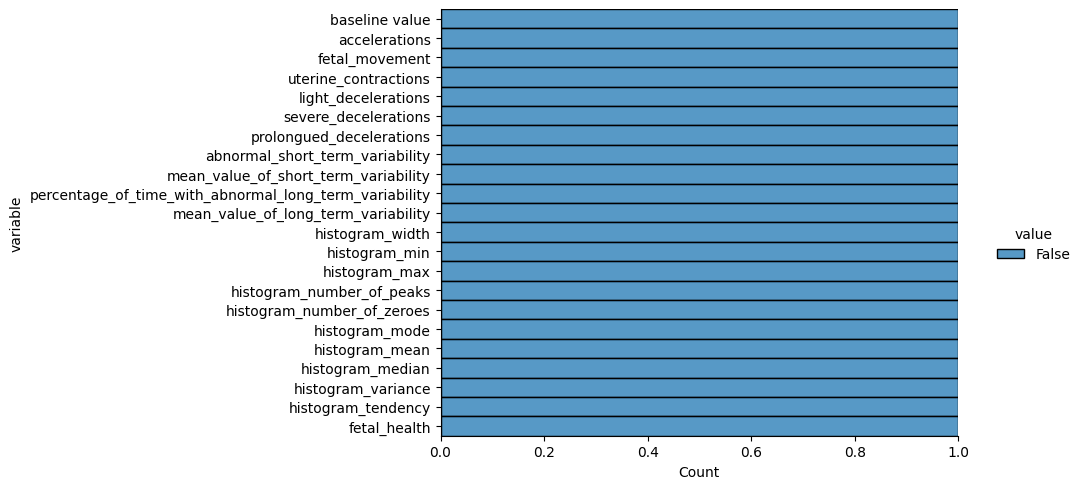

In [4]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', 
                                                hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

Según la información de la gráfica, ninguna variable tiene datos nulos

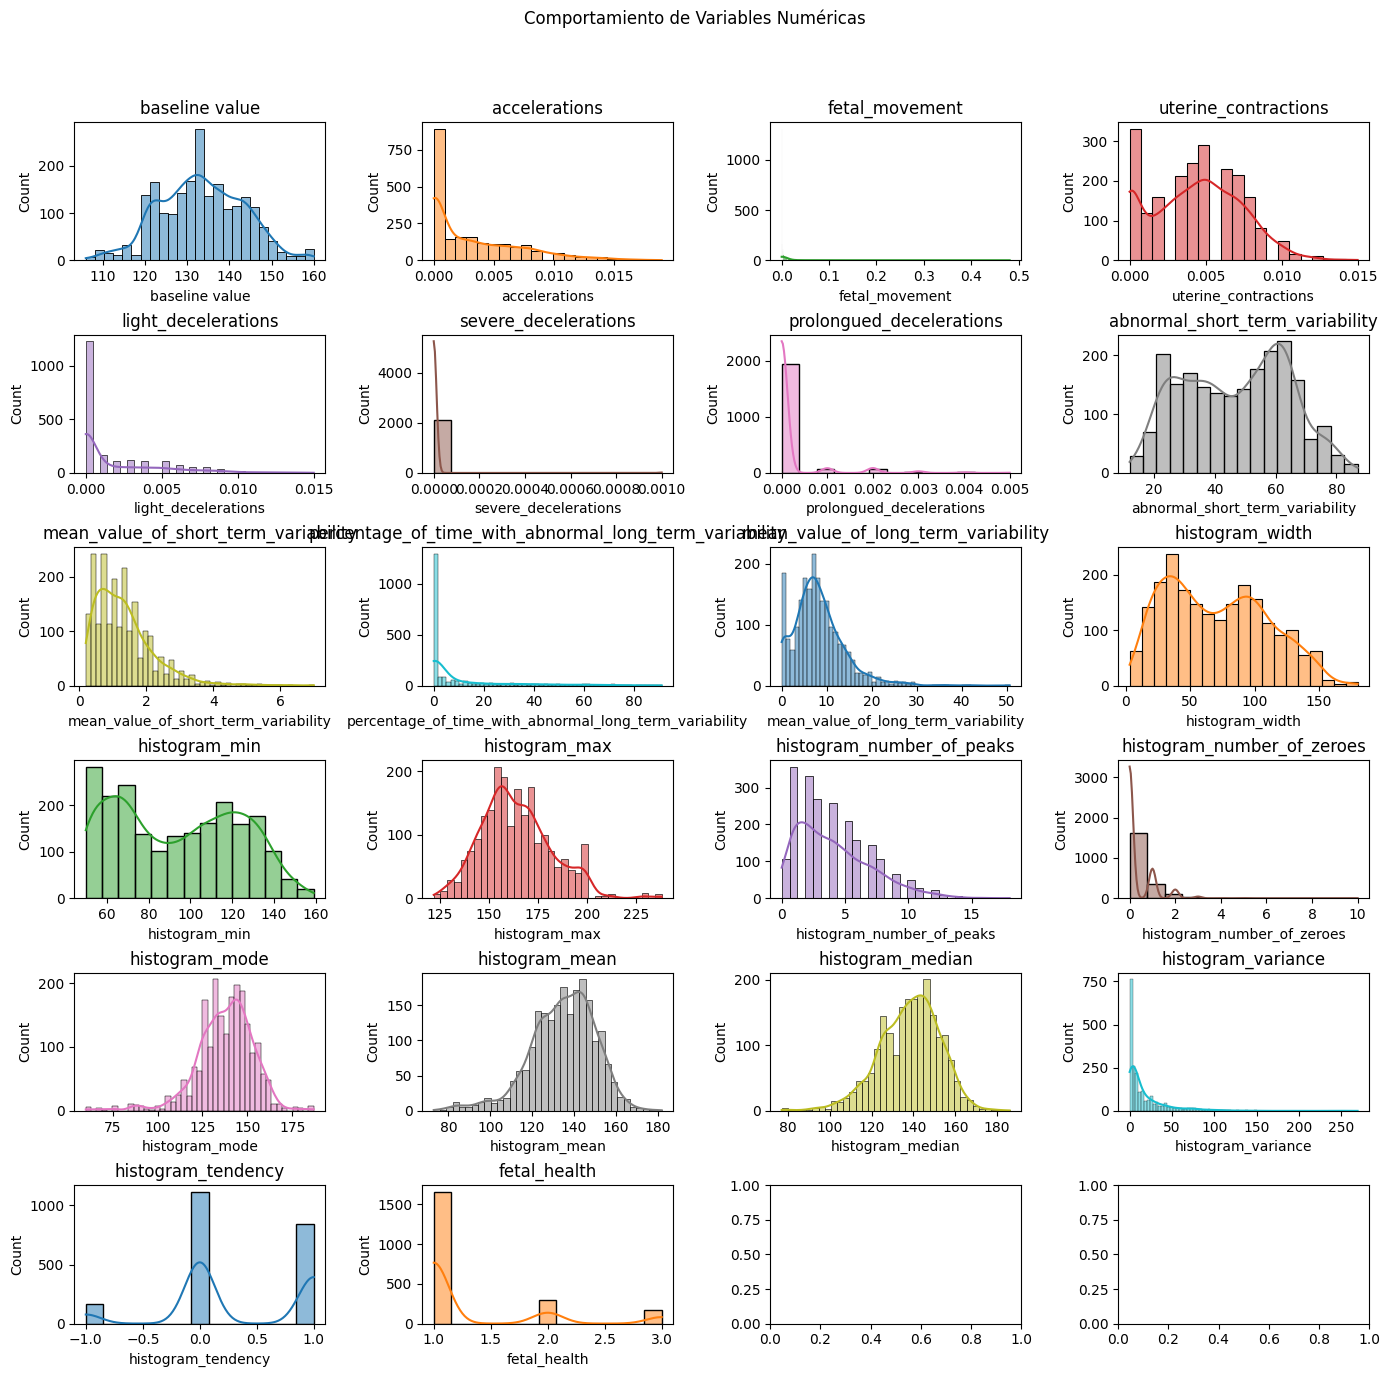

In [5]:
#Exploración univariada de los datos
##Para datos numéricos: histogramas de frecuencia
##Para datos categóricos: gráficos de torta

###HISTOGRAMAS DE FRECUENCIA
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, 
                kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

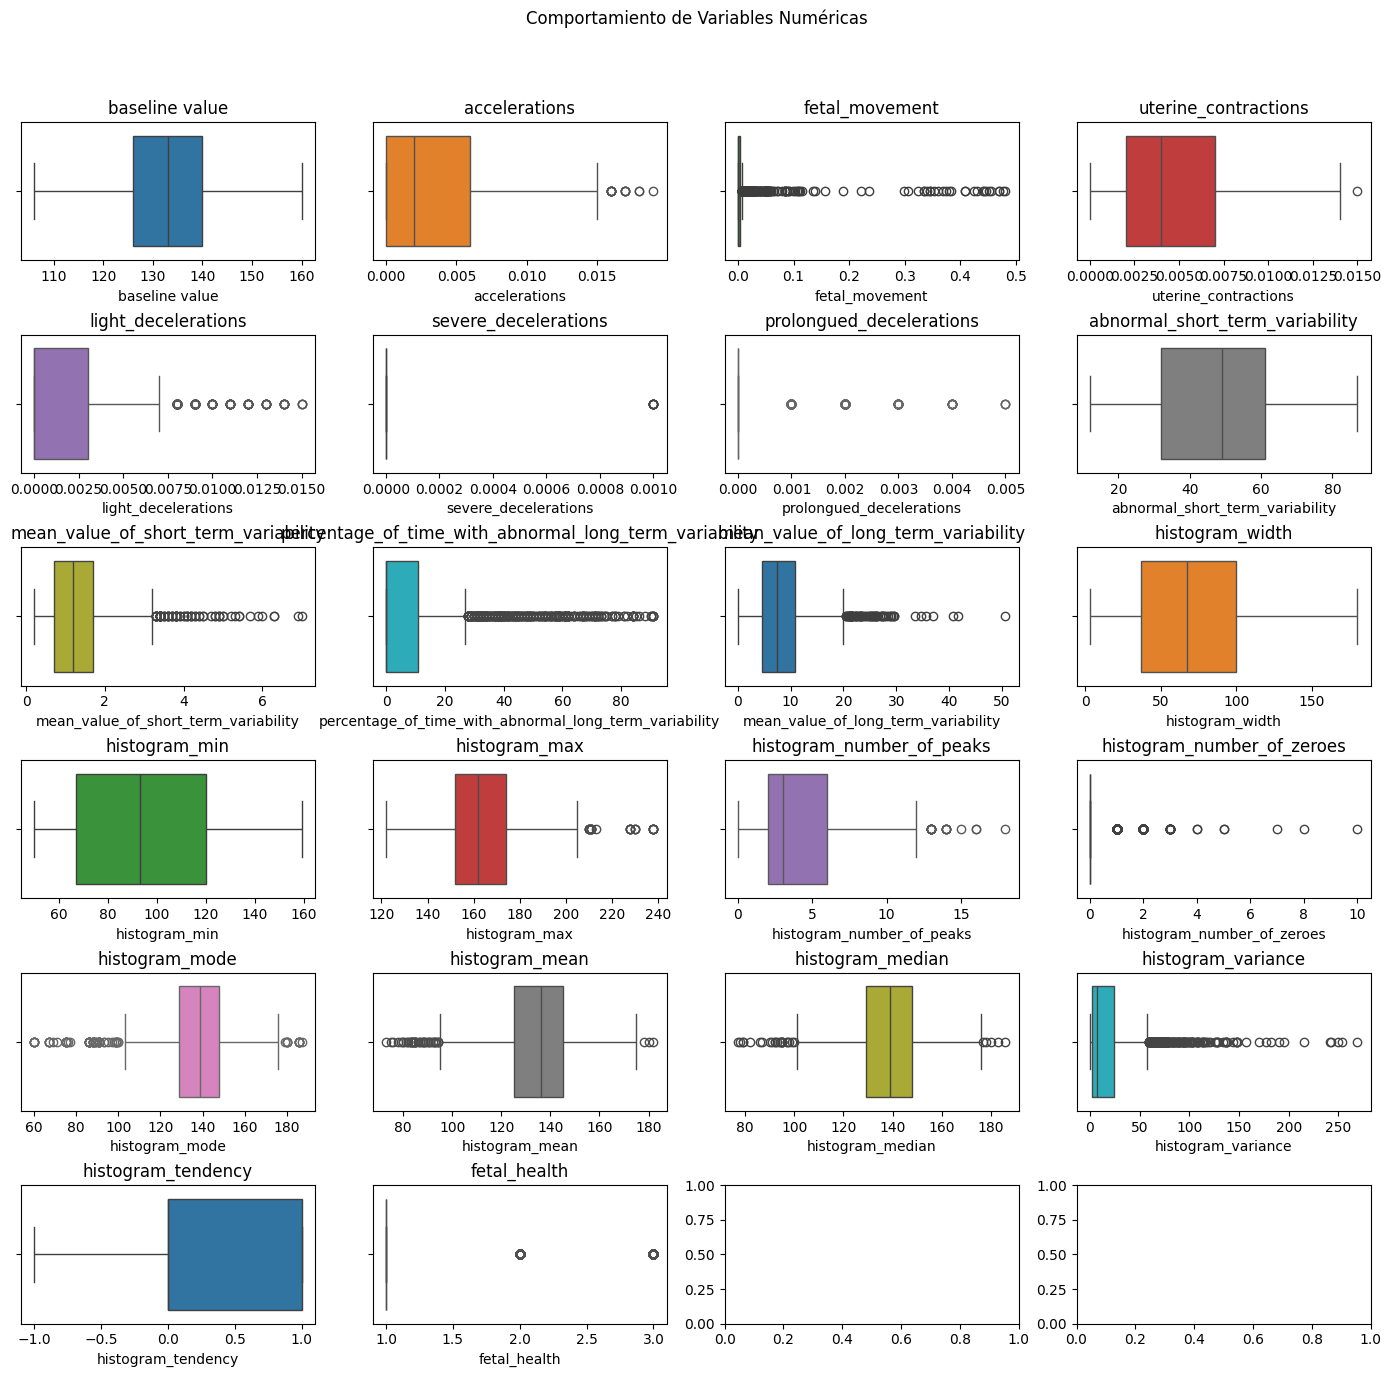

In [6]:
###CAJAS Y BIGOTES
fig, ax = plt.subplots(6, 4, figsize = (14, 14))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.boxplot(data = data, x = col, 
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

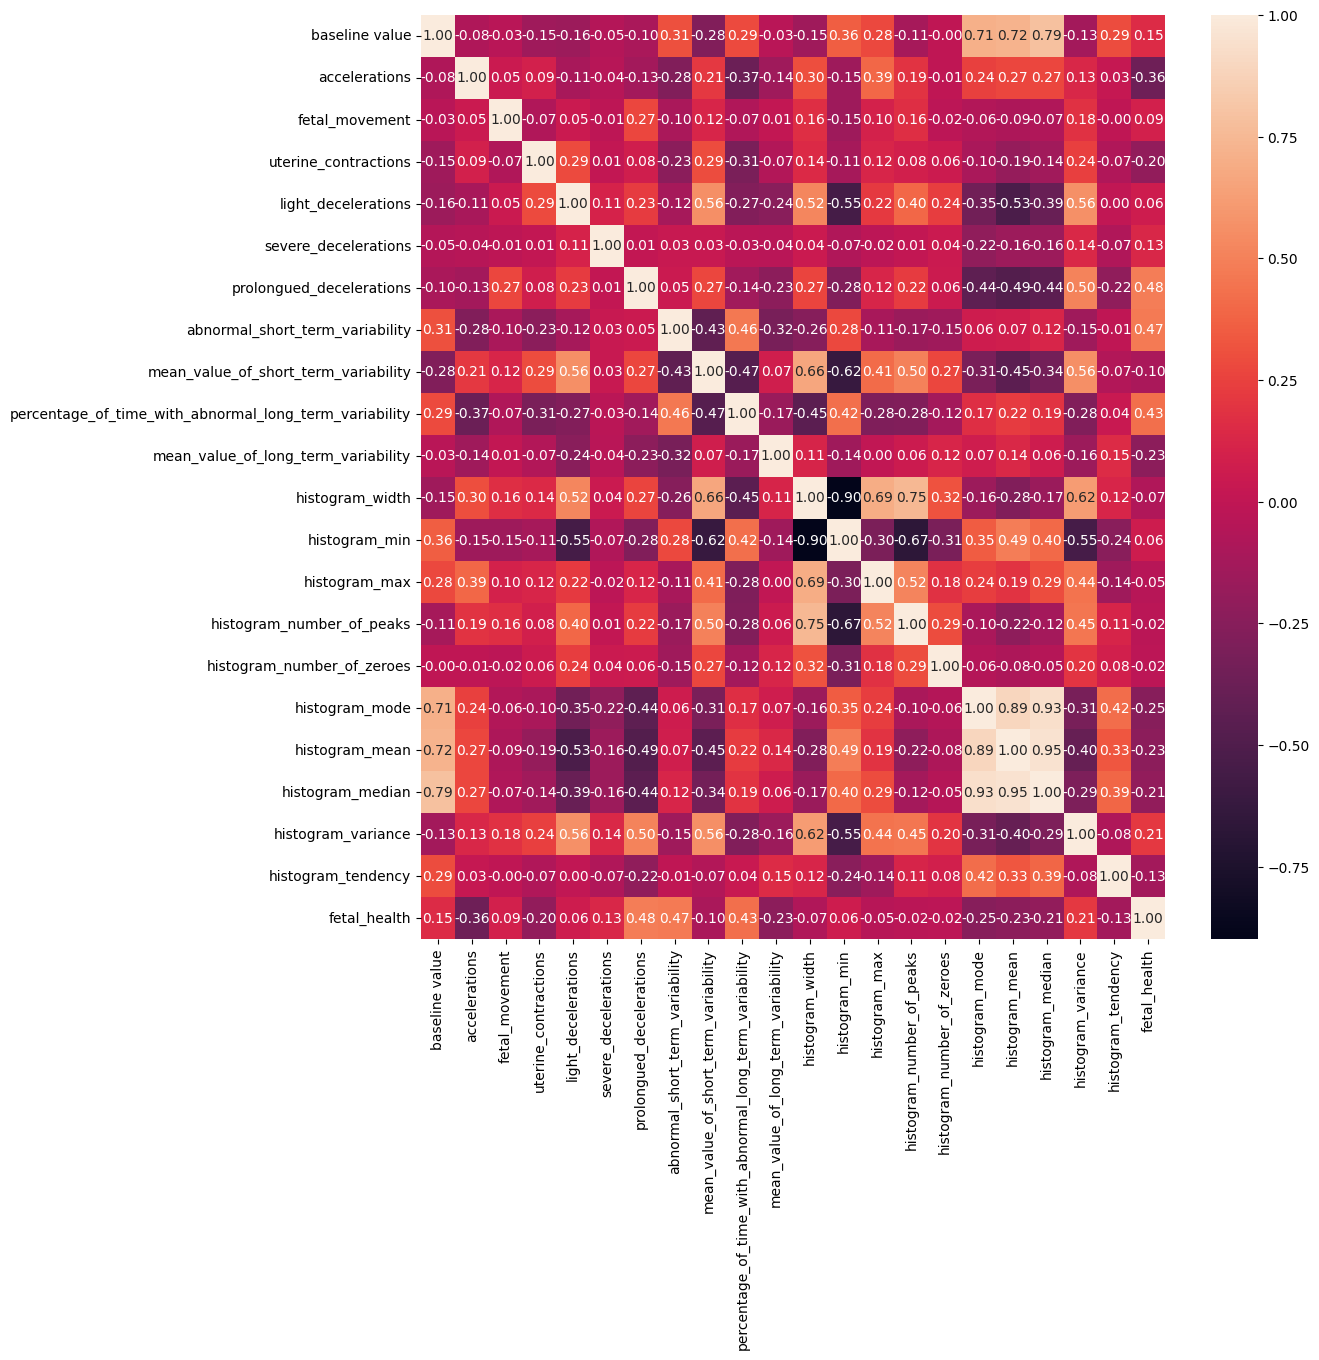

In [7]:
# Mapa de correlación
plt.figure(figsize=(12, 12))
sb.heatmap(data.corr(numeric_only=True), annot = True, fmt = '.2f')
plt.show()

In [8]:
# fetal_movements podría ser ignorada (muy concentrada y muy poca correlación)
# severe_decelerations candidata a eliminar (variable casi constante, poco aporte)

# eliminar histogram_mode y histogram_mean, me quedo con histogram_median (multicolinealidad)
# elimino histogram_width porque es una variable derivada de histogram_min y histogram_max (multicolinealidad)

# histogram_tendency y la Y fetal_health, tratar como categórica

# **6. Preparación de los datos**
- Ignorar las variables poco representativas
- Balancear la variable y (la variable que estoy supervisando, fetal_health, esta desbalanceada)
- Escalar variables numéricas y codificar variables categóricas
- Separar en conjuntos de entrenamiento y validación

In [9]:
# Pasar histogram_tendency a tipo categórico
data['histogram_tendency'] = data['histogram_tendency'].astype('str')

In [10]:
# Se descarta fetal_movements y severe_decelerations por su baja variabilidad, variables muy sesgadas y con poca correlación con y.
data = data.drop(columns = ['fetal_movement', 'severe_decelerations'])

In [ ]:
# 1
data = data.drop(columns = ['histogram_mode', 'histogram_mean'])

In [12]:
# Se descarta histogram_width porque es una variable derivada de histogram_min y histogram_max, lo que genera redundancia.
data = data.drop(columns = ['histogram_width'])

In [13]:
#BALANCEO DE Y
data_high = data[data['fetal_health'] == 1]
data_medium = data[data['fetal_health'] == 2]
data_low = data[data['fetal_health'] == 3]
print(f'El tamaño de la clase 1 es: {data_high.shape}\nEl tamaño de la clase 2 es: {data_medium.shape}\nEl tamaño de la clase 3 es: {data_low.shape}')

# Se filtra por filas

El tamaño de la clase 1 es: (1655, 17)
El tamaño de la clase 2 es: (295, 17)
El tamaño de la clase 3 es: (176, 17)


In [14]:
# Se realiza oversampling de las clases minoritarias para igualar su tamaño
# al de la clase mayoritaria, permitiendo la repetición de registros 
data_medium_re = data_medium.sample(data_high.shape[0], replace = True)
data_low_re = data_low.sample(data_high.shape[0], replace = True)
data_balanced = pd.concat([data_high, data_medium_re, data_low_re])
data_balanced.reset_index(drop=True, inplace=True)
data_balanced.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4965 entries, 0 to 4964
Data columns (total 17 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          4965 non-null   float64
 1   accelerations                                           4965 non-null   float64
 2   uterine_contractions                                    4965 non-null   float64
 3   light_decelerations                                     4965 non-null   float64
 4   prolongued_decelerations                                4965 non-null   float64
 5   abnormal_short_term_variability                         4965 non-null   float64
 6   mean_value_of_short_term_variability                    4965 non-null   float64
 7   percentage_of_time_with_abnormal_long_term_variability  4965 non-null   float64
 8   mean_value_of_long_term_variability   

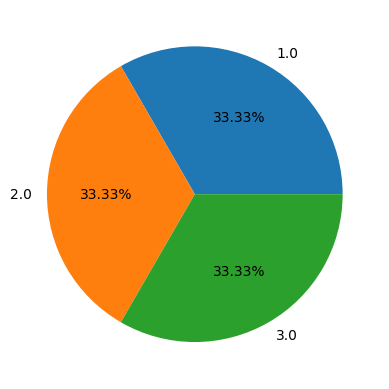

In [15]:
plt.pie(x = data_balanced.fetal_health.value_counts(), labels = data_balanced.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

In [16]:
# Separar X y Y
X = data_balanced.drop('fetal_health', axis = 1)
y = data_balanced[['fetal_health']]
print(f'El tamaño de X es: {X.shape} y el tamaño de y es: {y.shape}')

El tamaño de X es: (4965, 16) y el tamaño de y es: (4965, 1)


In [17]:
# Transformar X
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

num_col = X.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_col = X.select_dtypes(include = ['object']).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output = False))])
preprocessor = ColumnTransformer(transformers = [('num', num_transformer, num_col),
                                                 ('cat', cat_transformer, cat_col)],
                                                 remainder = 'passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['baseline value', 'accelerations',
                                  'uterine_contractions', 'light_decelerations',
                                  'prolongued_decelerations',
                                  'abnormal_short_term_variability',
                                  'mean_value_of_short_term_variability',
                                  'percentage_of_time_with_abnormal_long_term_variability',
                                  'mean_value_of_long_term_variability',
                                  'histogram_min', 'histogram_max',
                                  'histogram_number_of_peaks',
                                  'histogram_number_of_zeroes',
                                  'histogram_median', 'histogram_variance']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(sparse_output=False))]),
                                 ['histogram_tendency'])])

In [18]:
X_pre = preprocessor.fit_transform(X)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
X_pro = pd.DataFrame(X_pre, columns = labels)
X_pro.head(10)

,baseline value,accelerations,uterine_contractions,light_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_median,histogram_variance,histogram_tendency_-1.0,histogram_tendency_0.0,histogram_tendency_1.0
0,0.481481,0.315789,0.400000,0.200000,0.0,0.066667,0.279412,0.0,0.205128,0.165138,0.655172,0.333333,0.1,0.577982,0.044610,0.0,1.0,0.0
1,0.500000,0.157895,0.533333,0.200000,0.0,0.053333,0.279412,0.0,0.264300,0.165138,0.655172,0.277778,0.1,0.559633,0.048327,0.0,1.0,0.0
2,0.518519,0.157895,0.533333,0.200000,0.0,0.053333,0.323529,0.0,0.453649,0.027523,0.413793,0.611111,0.0,0.550459,0.048327,0.0,0.0,1.0
3,0.481481,0.368421,0.533333,0.000000,0.0,0.053333,0.323529,0.0,0.392505,0.027523,0.413793,0.500000,0.0,0.559633,0.040892,0.0,0.0,1.0
4,0.462963,0.263158,0.533333,0.200000,0.0,0.213333,0.176471,0.0,0.254438,0.348624,0.275862,0.277778,0.0,0.550459,0.026022,0.0,0.0,1.0
5,0.462963,0.473684,0.400000,0.133333,0.0,0.213333,0.191176,0.0,0.106509,0.192661,0.310345,0.111111,0.0,0.587156,0.037175,0.0,0.0,1.0
6,0.444444,0.315789,0.266667,0.333333,0.2,0.120000,0.308824,0.0,0.155819,0.155963,0.448276,0.388889,0.0,0.532110,0.282528,0.0,1.0,0.0
7,0.444444,0.315789,0.266667,0.266667,0.2,0.093333,0.308824,0.0,0.171598,0.155963,0.448276,0.166667,0.0,0.513761,0.159851,0.0,1.0,0.0
8,0.444444,0.315789,0.333333,0.333333,0.0,0.160000,0.279412,0.0,0.214990,0.027523,0.482759,0.277778,0.0,0.559633,0.260223,0.0,0.0,1.0
9,0.444444,0.157895,0.400000,0.266667,0.2,0.146667,0.250000,0.0,0.173570,0.082569,0.310345,0.333333,0.0,0.477064,0.133829,0.0,0.0,1.0


In [19]:
# Se separan las X y Y de entrenamiento y validación, con un 70% de entrenamiento
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pro, y, train_size = 0.7, random_state = 123)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}\nEl tamaño del conjunto de validación es: {X_test.shape} {y_test.shape}')

El tamaño del conjunto de entrenamiento es: (3475, 18) (3475, 1)
El tamaño del conjunto de validación es: (1490, 18) (1490, 1)


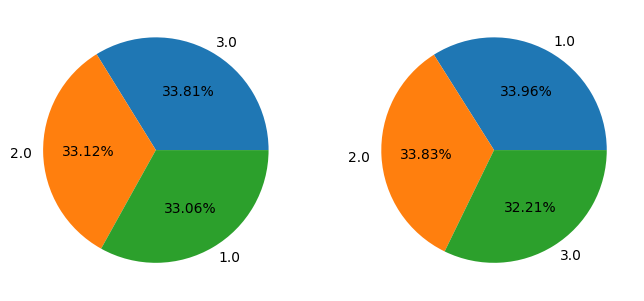

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (8, 8))
ax[0].pie(x = y_train.fetal_health.value_counts(), labels = y_train.fetal_health.value_counts().index, autopct = '%0.2f%%')
ax[1].pie(x = y_test.fetal_health.value_counts(), labels = y_test.fetal_health.value_counts().index, autopct = '%0.2f%%')
plt.show()

# **7. Modelado de Datos**

- Regresión Logística
- K Vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting
- Red Neuronal Artificial

In [21]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
# Busqueda de hiperparámetros y validación cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Se define el modelo pero sin hiperparámetros optimos aún
# 'saga' es un tipo específico de solver basado en descenso por gradiente estocástico mejorado
model_1 = LogisticRegression(solver = 'saga', random_state = 123)
# Define todas las combinaciones de hiperparámetros a probar (24 modelos)
param_grid = {'penalty':['l1', 'l2', 'elasticnet'], 'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}
# Validación cruzada
# Stratified: Mantiene la proporción de clases en cada fold
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
# Se crea el sistema automático para probar muchos modelos y escoger el mejor
clf_1 = GridSearchCV(estimator = model_1, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
# Se ejecuta la combinación de hiperparámetros y cross validation
clf_1.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=LogisticRegression(random_state=123, solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='f1_weighted')

In [22]:
# Se construye una tabla con todas las combinaciones de hiperparámetros y su desempeño (F1 promedio)
# clf_1.cv_results_ es un diccionario que guarda todo lo que pasó en Grid Search
validation = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,C,penalty,F1_score
9,1.000,l1,0.870915
13,10.000,l2,0.870221
12,10.000,l1,0.860207
15,100.000,l1,0.859916
19,1000.000,l2,0.859621
22,10000.000,l2,0.859341
18,1000.000,l1,0.859341
16,100.000,l2,0.859069
21,10000.000,l1,0.859067
10,1.000,l2,0.857905


In [23]:
#K Vecinos Más Cercanos
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier()
# Hiperparámetros a probar (numero de vecinos y tipo de distancia)
param_grid = {'n_neighbors':[3, 5, 9, 7, 11, 15, 101], 'p':[1, 2]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_2 = GridSearchCV(estimator = model_2, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_2.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 9, 7, 11, 15, 101], 'p': [1, 2]},
             scoring='f1_weighted')

In [24]:
validation = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,n_neighbors,p,F1_score
0,3,1,0.958420
1,3,2,0.954651
3,5,2,0.943699
2,5,1,0.942477
7,7,2,0.927282
6,7,1,0.926944
5,9,2,0.918709
4,9,1,0.916347
9,11,2,0.909353
8,11,1,0.905458


In [25]:
#Máquina de soporte vectorial
from sklearn.svm import SVC
model_3 = SVC(random_state=123)
# Hiperparámetros a probar (epsilon y kernel)
param_grid = {'C':[0.001, 0.01, 0.1, 10, 100], 'kernel':['poly','linear', 'rbf', 'sigmoid'], 'degree':[2, 3]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_3 = GridSearchCV(estimator = model_3, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_3.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=SVC(random_state=123), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 10, 100], 'degree': [2, 3],
                         'kernel': ['poly', 'linear', 'rbf', 'sigmoid']},
             scoring='f1_weighted')

In [26]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,C,degree,kernel,F1_score
36,100.000,3,poly,0.961465
34,100.000,2,rbf,0.959212
38,100.000,3,rbf,0.959212
28,10.000,3,poly,0.945655
32,100.000,2,poly,0.940236
26,10.000,2,rbf,0.939385
30,10.000,3,rbf,0.939385
24,10.000,2,poly,0.928355
33,100.000,2,linear,0.889824
37,100.000,3,linear,0.889824


La profundidad del árbol es: 18
Número de hojas: 126


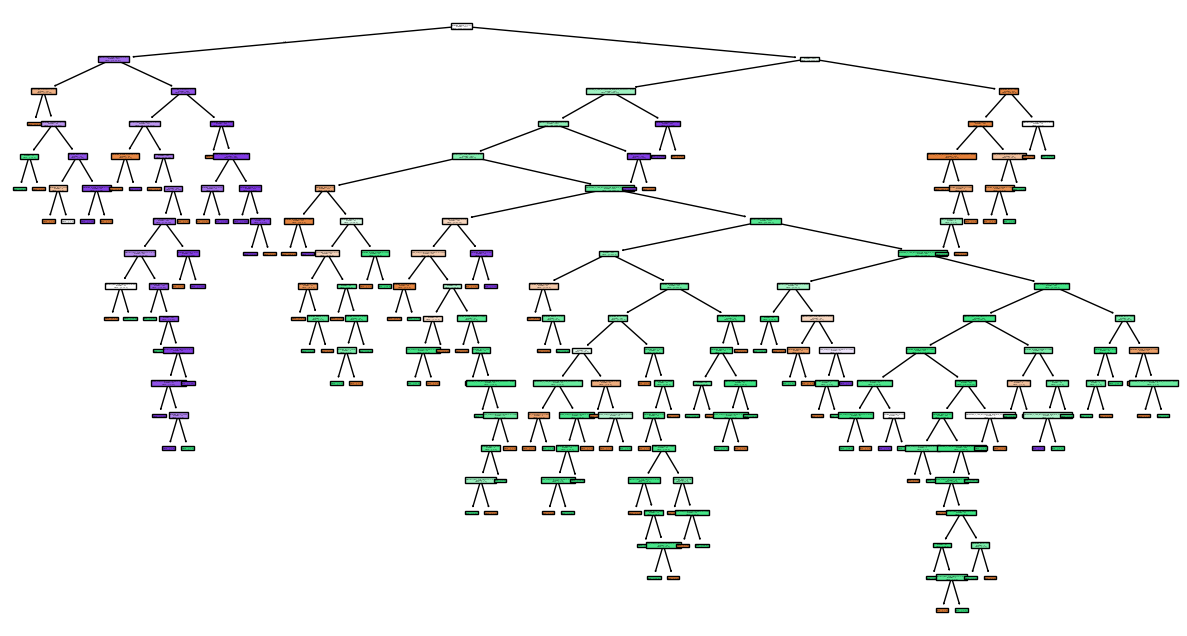

In [27]:
#Árbol de Decisión

# Se crea el arbol de decisión puro, sin hiperparámetros optimos, para visualizar su estructura 
# y decidir cuales hiperparámetros probar en la busqueda de Grid Search
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state = 123)
model_tree.fit(X_train, y_train)
print(f'La profundidad del árbol es: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize = (15, 8))
plot = plot_tree(decision_tree = model_tree, feature_names = labels, filled=True, impurity=False, ax = ax)

In [28]:
model_4 = DecisionTreeClassifier(random_state = 123)
# Hiperparámetros a probar (tipo de impureza, profundidad, numero de hojas y numero mínimo de muestras para dividir un nodo)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16], 
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_4 = GridSearchCV(estimator = model_4, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_4.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini', 'log_loss'],
                         'max_depth': [3, 5, 7, 10, 12, 14, 16],
                         'max_leaf_nodes': [None, 5, 10, 30, 50, 100, 130],
                         'min_samples_split': [2, 4, 6]},
             scoring='f1_weighted')

In [29]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,F1_score
399,log_loss,14,NaN,2,0.976559
105,entropy,14,NaN,2,0.976559
291,gini,16,130.0,2,0.976293
126,entropy,16,NaN,2,0.975972
420,log_loss,16,NaN,2,0.975972
...,...,...,...,...,...
4,entropy,3,5.0,4,0.766373
5,entropy,3,5.0,6,0.766373
297,log_loss,3,5.0,2,0.766373
299,log_loss,3,5.0,6,0.766373


MODELOS DE ENSAMBLE

In [30]:
#ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
model_5 = ExtraTreesClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16],
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_5 = GridSearchCV(estimator = model_5, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_5.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=ExtraTreesClassifier(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini', 'log_loss'],
                         'max_depth': [3, 5, 7, 10, 12, 14, 16],
                         'max_leaf_nodes': [None, 5, 10, 30, 50, 100, 130],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 200, 400, 500]},
             scoring='f1_weighted')

In [31]:
validation = pd.concat([pd.DataFrame(clf_5.cv_results_['params']),
                        pd.DataFrame(clf_5.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
1094,gini,16,NaN,2,400,0.987617
505,entropy,16,NaN,2,200,0.987615
1681,log_loss,16,NaN,2,200,0.987615
506,entropy,16,NaN,2,400,0.987615
1682,log_loss,16,NaN,2,400,0.987615
...,...,...,...,...,...,...
1024,gini,14,5.0,4,100,0.797608
1028,gini,14,5.0,6,100,0.797608
1020,gini,14,5.0,2,100,0.797608
940,gini,12,5.0,4,100,0.797608


In [32]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
model_6 = RandomForestClassifier(random_state = 123)
param_grid = {'criterion':['entropy', 'gini', 'log_loss'], 
              'max_depth':[3, 5, 7, 10, 12, 14, 16],
              'max_leaf_nodes':[None, 5, 10, 30, 50, 100, 130], 
              'min_samples_split':[2, 4, 6], 'n_estimators':[100, 200, 400, 500]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_6 = GridSearchCV(estimator = model_6, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_6.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=RandomForestClassifier(random_state=123), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini', 'log_loss'],
                         'max_depth': [3, 5, 7, 10, 12, 14, 16],
                         'max_leaf_nodes': [None, 5, 10, 30, 50, 100, 130],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 200, 400, 500]},
             scoring='f1_weighted')

In [33]:
validation = pd.concat([pd.DataFrame(clf_6.cv_results_['params']),
                        pd.DataFrame(clf_6.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,n_estimators,F1_score
420,entropy,14,NaN,2,100,0.984710
1596,log_loss,14,NaN,2,100,0.984710
1597,log_loss,14,NaN,2,200,0.984708
421,entropy,14,NaN,2,200,0.984708
1680,log_loss,16,NaN,2,100,0.984120
...,...,...,...,...,...,...
19,entropy,3,5.0,4,500,0.848694
1191,log_loss,3,5.0,2,500,0.848694
1195,log_loss,3,5.0,4,500,0.848694
1199,log_loss,3,5.0,6,500,0.848694


In [34]:
#AdaptativeBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
model_7 = AdaBoostClassifier(random_state = 123)
param_grid = {'learning_rate':[0.01, 0.1, 1, 10, 100], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_7 = GridSearchCV(estimator = model_7, param_grid = param_grid, cv = cv, scoring = 'f1_weighted', n_jobs = -1)
clf_7.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
             estimator=AdaBoostClassifier(random_state=123), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1, 10, 100],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='f1_weighted')

In [35]:
validation = pd.concat([pd.DataFrame(clf_7.cv_results_['params']),
                        pd.DataFrame(clf_7.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,learning_rate,n_estimators,F1_score
10,1.00,300,0.914030
11,1.00,400,0.912016
9,1.00,200,0.911237
8,1.00,100,0.906698
7,0.10,400,0.876810
6,0.10,300,0.853446
5,0.10,200,0.842706
4,0.10,100,0.813955
3,0.01,400,0.795097
2,0.01,300,0.764237


In [36]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_8 = GradientBoostingClassifier(random_state = 123)
param_grid = {'criterion':['friedman_mse', 'squared_error'], 'max_depth':[5,7,9,12],
              'max_leaf_nodes':[10,40,None], 'min_samples_split':[2,3], 'n_estimators':[100, 200, 300, 400]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_8 = RandomizedSearchCV(estimator = model_8, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 48)
clf_8.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
                   estimator=GradientBoostingClassifier(random_state=123),
                   n_iter=48, n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'max_depth': [5, 7, 9, 12],
                                        'max_leaf_nodes': [10, 40, None],
                                        'min_samples_split': [2, 3],
                                        'n_estimators': [100, 200, 300, 400]},
                   scoring='f1_weighted')

In [37]:
validation = pd.concat([pd.DataFrame(clf_8.cv_results_['params']),
                        pd.DataFrame(clf_8.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,n_estimators,min_samples_split,max_leaf_nodes,max_depth,criterion,F1_score
45,200,3,NaN,7,squared_error,0.987007
7,400,3,10.0,12,squared_error,0.986732
28,400,3,10.0,5,squared_error,0.986725
30,300,2,NaN,9,squared_error,0.986720
2,300,3,NaN,7,friedman_mse,0.986431
8,400,3,40.0,7,friedman_mse,0.986430
6,100,2,NaN,7,friedman_mse,0.986132
12,300,3,NaN,9,squared_error,0.985851
39,300,3,40.0,12,squared_error,0.985849
18,400,2,NaN,5,squared_error,0.985581


In [38]:
# Red Neuronal Artificial - Multilayer Perceptron
from sklearn.neural_network import MLPClassifier
model_9 = MLPClassifier(random_state = 123)
param_grid = {'hidden_layer_sizes':[(10,), (20, 10, 5), (20, 10), (20,), (50, 40, 30, 20, 10)],
            'activation':['identity', 'logistic', 'tanh', 'relu'], 'solver':['adam', 'lbfgs', 'sgd'],
            'learning_rate_init':[0.01, 0.1, 1, 10, 100], 'max_iter':[50, 70, 100, 200]}
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 123)
clf_9 = RandomizedSearchCV(estimator = model_9, param_distributions = param_grid, cv = cv, scoring = 'f1_weighted', 
                           n_jobs = -1, n_iter = 180)
clf_9.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=123, shuffle=True),
                   estimator=MLPClassifier(random_state=123), n_iter=180,
                   n_jobs=-1,
                   param_distributions={'activation': ['identity', 'logistic',
                                                       'tanh', 'relu'],
                                        'hidden_layer_sizes': [(10,),
                                                               (20, 10, 5),
                                                               (20, 10), (20,),
                                                               (50, 40, 30, 20,
                                                                10)],
                                        'learning_rate_init': [0.01, 0.1, 1, 10,
                                                               100],
                                        'max_iter': [50, 70, 100, 200],
                                        'solver': ['adam', 'lbfgs', 'sgd']},
                   scoring='f1_weighted')

In [39]:
validation = pd.concat([pd.DataFrame(clf_9.cv_results_['params']),
                        pd.DataFrame(clf_9.cv_results_['mean_test_score'], columns = ['F1_score'])], axis = 1)
validation.sort_values('F1_score', ascending = False)

,solver,max_iter,learning_rate_init,hidden_layer_sizes,activation,F1_score
149,lbfgs,200,100.0,"(20, 10)",tanh,0.967103
134,lbfgs,200,1.0,"(20, 10)",tanh,0.967103
177,lbfgs,200,0.1,"(20,)",tanh,0.957013
160,lbfgs,200,0.1,"(50, 40, 30, 20, 10)",tanh,0.955680
136,lbfgs,200,1.0,"(20,)",logistic,0.955641
...,...,...,...,...,...,...
122,sgd,50,10.0,"(10,)",identity,NaN
124,sgd,50,10.0,"(20, 10)",identity,NaN
150,sgd,70,0.1,"(50, 40, 30, 20, 10)",identity,NaN
152,sgd,200,10.0,"(50, 40, 30, 20, 10)",relu,NaN


# **8. Validación del modelo**
- Calcular las predicciones del conjunto de validación
- Calcular las métricas de desempeño
- Elegir el mejor modelo

In [40]:
model_rl = clf_1.best_estimator_
pred_rl = model_rl.predict(X_test)
model_knn = clf_2.best_estimator_
pred_knn = model_knn.predict(X_test)
model_svm = clf_3.best_estimator_
pred_svm = model_svm.predict(X_test)
model_dt = clf_4.best_estimator_
pred_dt = model_dt.predict(X_test)
model_et = clf_5.best_estimator_
pred_et = model_et.predict(X_test)
model_rf = clf_6.best_estimator_
pred_rf = model_rf.predict(X_test)
model_ab = clf_7.best_estimator_
pred_ab = model_ab.predict(X_test)
model_gb = clf_8.best_estimator_
pred_gb = model_gb.predict(X_test)
model_rna = clf_9.best_estimator_
pred_rna = model_rna.predict(X_test)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

In [42]:
def calculo_metricas(y_test, y_pred, modelo):
    print(f'Reporte de Clasificación - {modelo}')
    print(classification_report(y_test, y_pred))
    sb.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
    plt.show()

Reporte de Clasificación - Regresión Logística
              precision    recall  f1-score   support

         1.0       0.95      0.85      0.90       506
         2.0       0.78      0.87      0.82       504
         3.0       0.86      0.86      0.86       480

    accuracy                           0.86      1490
   macro avg       0.87      0.86      0.86      1490
weighted avg       0.87      0.86      0.86      1490



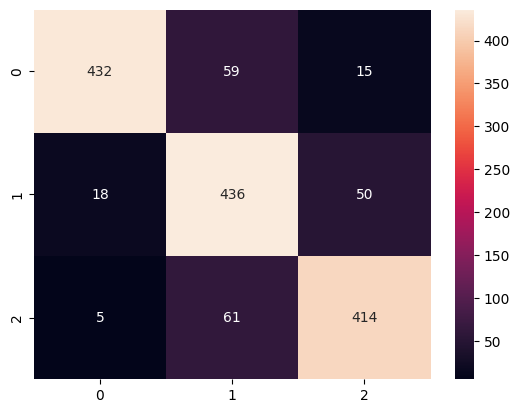

In [43]:
# Regresion Logistica
calculo_metricas(y_test, pred_rl, 'Regresión Logística')

Reporte de Clasificación - K Vecinos Más Cercanos
              precision    recall  f1-score   support

         1.0       0.97      0.92      0.95       506
         2.0       0.93      0.98      0.95       504
         3.0       0.99      1.00      1.00       480

    accuracy                           0.96      1490
   macro avg       0.97      0.97      0.96      1490
weighted avg       0.97      0.96      0.96      1490



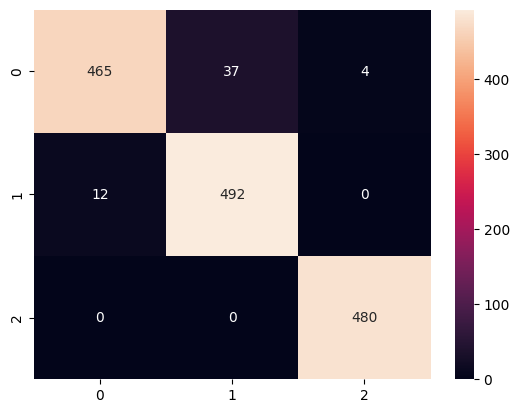

In [44]:
# K Vecinos Más Cercanos
calculo_metricas(y_test, pred_knn, 'K Vecinos Más Cercanos')

Reporte de Clasificación - Maquina de Soporte Vectorial
              precision    recall  f1-score   support

         1.0       0.99      0.92      0.95       506
         2.0       0.91      0.98      0.95       504
         3.0       0.99      0.99      0.99       480

    accuracy                           0.96      1490
   macro avg       0.96      0.96      0.96      1490
weighted avg       0.96      0.96      0.96      1490



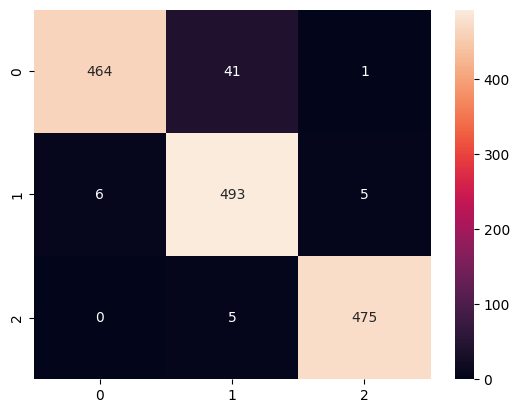

In [45]:
# Maquina de Soporte Vectorial
calculo_metricas(y_test, pred_svm, 'Maquina de Soporte Vectorial')

Reporte de Clasificación - Árbol de Decisión
              precision    recall  f1-score   support

         1.0       0.99      0.96      0.98       506
         2.0       0.97      0.99      0.98       504
         3.0       0.99      1.00      0.99       480

    accuracy                           0.98      1490
   macro avg       0.98      0.98      0.98      1490
weighted avg       0.98      0.98      0.98      1490



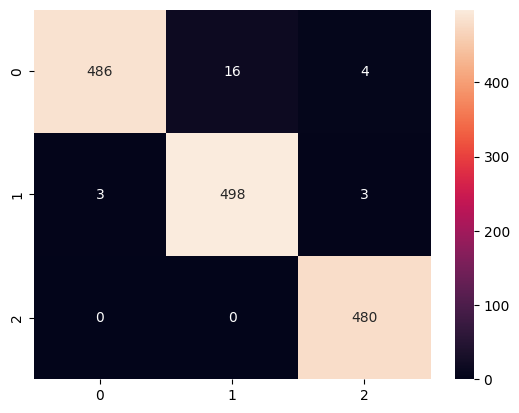

In [46]:
# Decision Tree
calculo_metricas(y_test, pred_dt, 'Árbol de Decisión')

Reporte de Clasificación - Extra Tree Classifier
              precision    recall  f1-score   support

         1.0       0.99      0.97      0.98       506
         2.0       0.97      0.99      0.98       504
         3.0       1.00      1.00      1.00       480

    accuracy                           0.99      1490
   macro avg       0.99      0.99      0.99      1490
weighted avg       0.99      0.99      0.99      1490



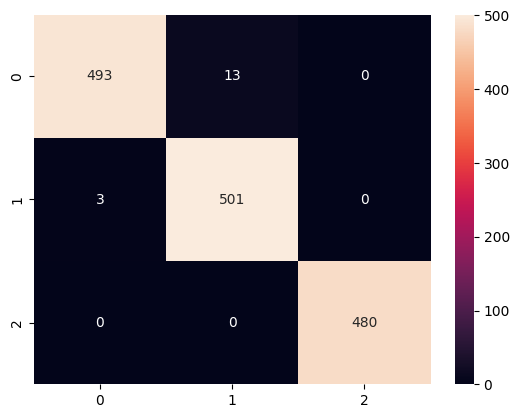

In [47]:
# Extra Tree Classifier
calculo_metricas(y_test, pred_et, 'Extra Tree Classifier')

Reporte de Clasificación - Random Forest Classifier
              precision    recall  f1-score   support

         1.0       0.99      0.97      0.98       506
         2.0       0.97      0.99      0.98       504
         3.0       1.00      1.00      1.00       480

    accuracy                           0.99      1490
   macro avg       0.99      0.99      0.99      1490
weighted avg       0.99      0.99      0.99      1490



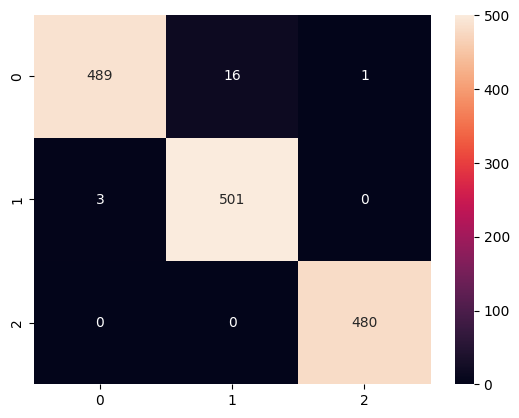

In [48]:
# Random Forest Classifier
calculo_metricas(y_test, pred_rf, 'Random Forest Classifier')

Reporte de Clasificación - Adaptative Boosting Classifier
              precision    recall  f1-score   support

         1.0       0.91      0.89      0.90       506
         2.0       0.89      0.91      0.90       504
         3.0       0.98      0.98      0.98       480

    accuracy                           0.93      1490
   macro avg       0.93      0.93      0.93      1490
weighted avg       0.93      0.93      0.93      1490



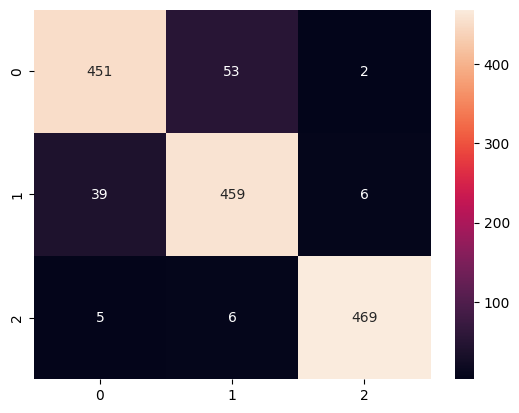

In [49]:
# Adaptative Boosting Classifier
calculo_metricas(y_test, pred_ab, 'Adaptative Boosting Classifier')

Reporte de Clasificación - Gradient Boosting Classifier
              precision    recall  f1-score   support

         1.0       0.99      0.98      0.99       506
         2.0       0.99      0.99      0.99       504
         3.0       1.00      1.00      1.00       480

    accuracy                           0.99      1490
   macro avg       0.99      0.99      0.99      1490
weighted avg       0.99      0.99      0.99      1490



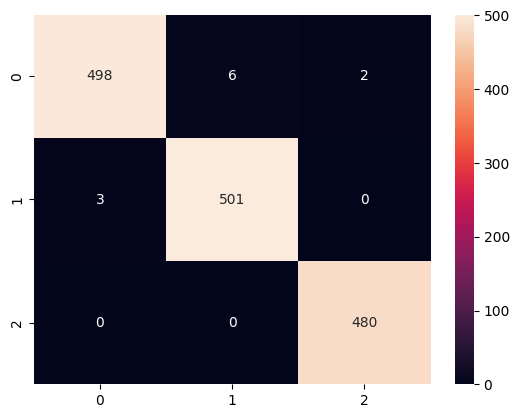

In [50]:
# Gradient Boosting Classifier
calculo_metricas(y_test, pred_gb, 'Gradient Boosting Classifier')

Reporte de Clasificación - Perceptron Multicapa
              precision    recall  f1-score   support

         1.0       0.98      0.93      0.95       506
         2.0       0.93      0.98      0.95       504
         3.0       0.99      1.00      0.99       480

    accuracy                           0.97      1490
   macro avg       0.97      0.97      0.97      1490
weighted avg       0.97      0.97      0.97      1490



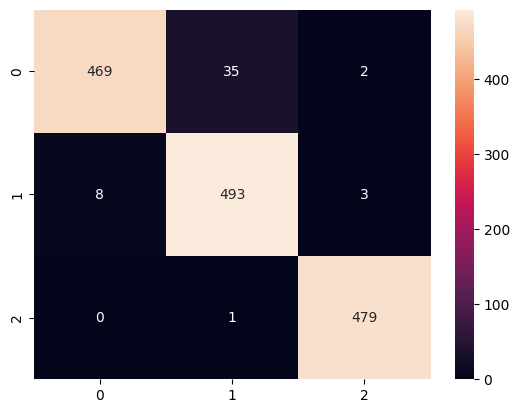

In [51]:
# Perceptron multicapa
calculo_metricas(y_test, pred_rna, 'Perceptron Multicapa')

# **9. Despliegue del Modelo**
- Construir el Pipeline
- Almacenar el Pipeline en un esquema externo

In [53]:
data = pd.read_csv('datos_caso_2.csv')
target = 'fetal_health'
X = data.drop(columns=target)
y = data[[target]]

In [63]:
# Selección de características
ignored = ['fetal_movements', 'severe_decelerations', 'histogram_mode', 'histogram_mean', 'histogram_width']
all_num = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
all_cat = X.select_dtypes(include=['object']).columns.to_list()
num_features = [col for col in all_num if col not in ignored]
cat_features = [col for col in all_cat if col not in ignored]

In [64]:
# Imputación de características
from sklearn.impute import SimpleImputer, KNNImputer
num_pipe = Pipeline(steps=[('num_imputer', KNNImputer()), ('scaler', MinMaxScaler())])
num_pipe

Pipeline(steps=[('num_imputer', KNNImputer()), ('scaler', MinMaxScaler())])

In [65]:
cat_pipe = Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(sparse_output=False))])
cat_pipe

Pipeline(steps=[('cat_imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(sparse_output=False))])

In [66]:
# Se usa el modelo que mejor desempeño tuvo en el f1_score, que no este sobreajustado, de menor complejidad computacional
# y que tenga una matriz de confusión balanceada.
model_gb

GradientBoostingClassifier(criterion='squared_error', max_depth=7,
                           min_samples_split=3, n_estimators=200,
                           random_state=123)

In [67]:
preprocessor = ColumnTransformer(transformers=[('num', num_pipe, num_features),
                                               ('cat', cat_pipe, cat_features)], remainder='drop')
model = GradientBoostingClassifier(criterion='squared_error', max_depth=7,
                           min_samples_split=3, n_estimators=200,
                           random_state=123)
pipe_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
pipe_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['baseline value',
                                                   'accelerations',
                                                   'fetal_movement',
                                                   'uterine_contractions',
                                                   'light_decelerations',
                                                   'prolongued_decelerations',
                                                   'abnormal_short_term_variability',
                                                   'mean_value_of_short_term_variability',
                                                   'percentage...
                                                   'histogram_number_of_zeroes',
                                                   'histogram_median',
                                                   'histogram_variance',
                                                   'histogram_tendency']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  [])])),
                ('model',
                 GradientBoostingClassifier(criterion='squared_error',
                                            max_depth=7, min_samples_split=3,
                                            n_estimators=200,
                                            random_state=123))])

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)
pipe_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['baseline value',
                                                   'accelerations',
                                                   'fetal_movement',
                                                   'uterine_contractions',
                                                   'light_decelerations',
                                                   'prolongued_decelerations',
                                                   'abnormal_short_term_variability',
                                                   'mean_value_of_short_term_variability',
                                                   'percentage...
                                                   'histogram_number_of_zeroes',
                                                   'histogram_median',
                                                   'histogram_variance',
                                                   'histogram_tendency']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  [])])),
                ('model',
                 GradientBoostingClassifier(criterion='squared_error',
                                            max_depth=7, min_samples_split=3,
                                            n_estimators=200,
                                            random_state=123))])

In [69]:
import joblib
joblib.dump(pipe_model, 'fetal_health_model.pkl')


['fetal_health_model.pkl']

In [70]:
model = joblib.load('fetal_health_model.pkl')
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['baseline value',
                                                   'accelerations',
                                                   'fetal_movement',
                                                   'uterine_contractions',
                                                   'light_decelerations',
                                                   'prolongued_decelerations',
                                                   'abnormal_short_term_variability',
                                                   'mean_value_of_short_term_variability',
                                                   'percentage...
                                                   'histogram_number_of_zeroes',
                                                   'histogram_median',
                                                   'histogram_variance',
                                                   'histogram_tendency']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  [])])),
                ('model',
                 GradientBoostingClassifier(criterion='squared_error',
                                            max_depth=7, min_samples_split=3,
                                            n_estimators=200,
                                            random_state=123))])

In [71]:
model.predict(X_test)

array([1., 1., 1., 1., 3., 1., 2., 1., 1., 1., 1., 2., 1., 1., 2., 1., 1.,
       2., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 1., 1., 1., 1., 1., 2., 1., 2., 1., 1., 1., 3., 1.,
       1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 3., 1., 1., 3., 3., 1., 1.,
       1., 1., 2., 3., 2., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 3., 1., 3., 1., 1.,
       1., 1., 3., 1., 1., 1., 1., 3., 1., 1., 3., 1., 1., 2., 1., 1., 2.,
       2., 2., 2., 1., 1., 1., 2., 1., 2., 2., 1., 2., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 2., 3., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 2., 1., 2., 3., 1., 1.,
       1., 2., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1., 3., 1., 1., 1., 1.,
       1., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2., 1., 1., 1., 1.,
       1., 1., 1., 2., 1.

In [72]:
model.feature_names_in_

array(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations',
       'severe_decelerations', 'prolongued_decelerations',
       'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency'],
      dtype=object)

In [74]:
new_data = pd.DataFrame({
    'baseline value': [120, 100, 150, 90, 160],
    'accelerations': [0.003, 0.000, 0.005, 0.000, 0.006],
    'fetal_movement': [0.1, 0.0, 0.2, 0.0, 0.3],
    'uterine_contractions': [0.002, 0.001, 0.004, 0.001, 0.005],
    'light_decelerations': [0.0, 0.2, 0.1, 0.3, 0.2],
    'severe_decelerations': [0.0, 0.1, 0.0, 0.2, 0.1],
    'prolongued_decelerations': [0.0, 0.1, 0.0, 0.2, 0.1],
    'abnormal_short_term_variability': [20, 50, 15, 60, 10],
    'mean_value_of_short_term_variability': [0.5, 0.2, 0.7, 0.1, 0.8],
    'percentage_of_time_with_abnormal_long_term_variability': [10, 40, 5, 50, 3],
    'mean_value_of_long_term_variability': [8, 3, 10, 2, 11],
    'histogram_width': [70, 120, 60, 130, 55],
    'histogram_min': [100, 80, 110, 75, 115],
    'histogram_max': [160, 190, 150, 200, 145],
    'histogram_number_of_peaks': [3, 6, 2, 7, 1],
    'histogram_number_of_zeroes': [0, 3, 0, 4, 0],
    'histogram_mode': [120, 90, 140, 85, 145],
    'histogram_mean': [125, 95, 135, 90, 140],
    'histogram_median': [123, 92, 133, 88, 138],
    'histogram_variance': [20, 50, 15, 60, 10],
    'histogram_tendency': [0, 1, 0, 1, 0]
})
model.predict(new_data)

array([1., 3., 1., 3., 2.])